<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Entangling Feature Maps and Data Re-Uploading

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `2.2`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.circuit.library import zz_feature_map

import pennylane as qml

<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We keep the same idea as in the main notebook, but now sweep several values of the interaction strength `gamma` and identify which pair of samples changes the most.

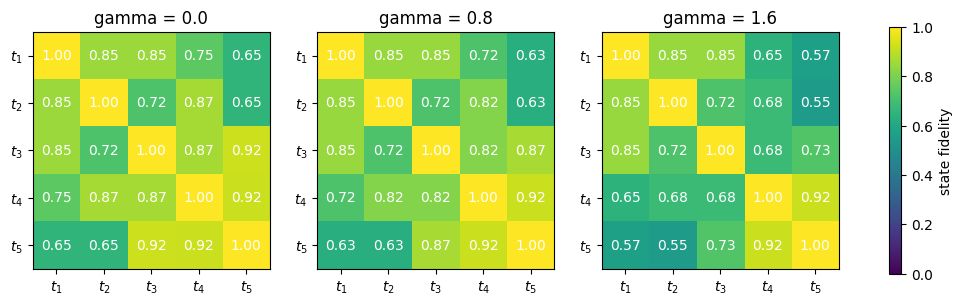

Largest off-diagonal change: 0.1947134952700743
Affected pair: $t_3$ $t_5$


In [2]:
def local_angle_map(phi):
    qc = QuantumCircuit(2)
    for q, angle in enumerate(phi):
        qc.ry(angle, q)
    return qc


def entangling_angle_map(phi, gamma=1.4):
    qc = QuantumCircuit(2)
    for q, angle in enumerate(phi):
        qc.ry(angle, q)
    qc.rzz(gamma * phi[0] * phi[1], 0, 1)
    return qc


def fidelity_matrix(builder, samples):
    n = len(samples)
    matrix = np.zeros((n, n))
    states = [Statevector.from_instruction(builder(sample)) for sample in samples]
    for a in range(n):
        for b in range(n):
            matrix[a, b] = state_fidelity(states[a], states[b])
    return matrix


samples_task = [
    np.array([0.20, 0.20]),
    np.array([0.20, 1.00]),
    np.array([1.00, 0.20]),
    np.array([0.95, 0.95]),
    np.array([1.40, 0.60]),
]
labels_task = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$"]
gammas = [0.0, 0.8, 1.6]

matrices = {
    gamma: fidelity_matrix(lambda x, g=gamma: entangling_angle_map(x, gamma=g), samples_task)
    for gamma in gammas
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, gamma in zip(axes, gammas):
    matrix = matrices[gamma]
    image = ax.imshow(matrix, vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(labels_task)), labels_task)
    ax.set_yticks(range(len(labels_task)), labels_task)
    ax.set_title(f"gamma = {gamma}")
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, f"{matrix[row, col]:.2f}", ha="center", va="center", color="white")

fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.8, label="state fidelity")
plt.show()

difference = np.abs(matrices[1.6] - matrices[0.0])
np.fill_diagonal(difference, -np.inf)
max_row, max_col = np.unravel_index(np.argmax(difference), difference.shape)

print("Largest off-diagonal change:", difference[max_row, max_col])
print("Affected pair:", labels_task[max_row], labels_task[max_col])

A typical outcome is that the largest change appears in a pair whose two features are jointly large or strongly unbalanced, because the entangling phase depends on the product of coordinates. This illustrates the role of a data-dependent interaction term: it can separate or cluster samples according to correlations, not only according to one feature at a time.

<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

We compare four ZZ-style encodings of the same four-feature sample and inspect how the circuit cost grows as we add repetitions and denser entanglement.

In [3]:
features = [0.20, 0.50, 0.90, 1.10]
configs = [
    (1, "linear"),
    (1, "full"),
    (2, "linear"),
    (2, "full"),
]

summary = []
for reps, entanglement in configs:
    circuit = zz_feature_map(feature_dimension=len(features), reps=reps, entanglement=entanglement)
    encoded = circuit.assign_parameters(features)
    decomposed = encoded.decompose()
    summary.append(
        {
            "reps": reps,
            "entanglement": entanglement,
            "depth": decomposed.depth(),
            "ops": dict(decomposed.count_ops()),
        }
    )

for item in summary:
    print(item)

{'reps': 1, 'entanglement': 'linear', 'depth': 11, 'ops': {'u': 11, 'cx': 6}}
{'reps': 1, 'entanglement': 'full', 'depth': 17, 'ops': {'u': 14, 'cx': 12}}
{'reps': 2, 'entanglement': 'linear', 'depth': 19, 'ops': {'u': 22, 'cx': 12}}
{'reps': 2, 'entanglement': 'full', 'depth': 31, 'ops': {'u': 28, 'cx': 24}}


Under a shallow-circuit budget, the most reasonable choice is usually `reps=1` with `entanglement="linear"`, because it injects pairwise structure while keeping the number of entangling gates moderate. If pairwise correlations are the priority and hardware depth is less restrictive, `reps=2` with `entanglement="full"` is the richer option, but it is also the most expensive one.

<a id="task3-solution"></a>

## Task 3 (optional, coding): One complete solution

We implement a small linear ZZ-style feature map directly in PennyLane, using the same circuit logic described in the notebook: Hadamards, local phase shifts, and `CNOT-PhaseShift-CNOT` interaction blocks.

In [4]:
features = np.array([0.20, 0.60, 1.10])
features_b = np.array([0.25, 1.00, 0.55])
dev_zz = qml.device("default.qubit", wires=3)

@qml.qnode(dev_zz)
def zz_feature_map_pl(features):
    n_wires = len(features)

    for q in range(n_wires):
        qml.Hadamard(wires=q)

    for q in range(n_wires):
        qml.PhaseShift(2 * features[q], wires=q)

    for q, r in [(0, 1), (1, 2)]:
        angle = 2 * (np.pi - features[q]) * (np.pi - features[r])
        qml.CNOT(wires=[q, r])
        qml.PhaseShift(angle, wires=r)
        qml.CNOT(wires=[q, r])

    return qml.state()

print(qml.draw(zz_feature_map_pl)(features))

state_a = zz_feature_map_pl(features)
state_b = zz_feature_map_pl(features_b)
overlap = np.abs(np.vdot(state_a, state_b)) ** 2

print("state overlap =", overlap)


0: ──H──Rϕ(0.40)─╭●────────────╭●──────────────────┤  State
1: ──H──Rϕ(1.20)─╰X──Rϕ(14.95)─╰X─╭●────────────╭●─┤  State
2: ──H──Rϕ(2.20)──────────────────╰X──Rϕ(10.38)─╰X─┤  State
state overlap = 0.04784769008907877


This solution is intentionally manual: the point is to translate the ZZ-style circuit idea into PennyLane gates instead of relying on a library-level feature-map constructor. That makes it easier to see which operations are responsible for local phases and which ones create pairwise interactions.

<a id="task4-solution"></a>

## Task 4 (coding): One complete solution

We extend the one-upload and two-upload examples by adding a third upload. To match what the plot is actually showing, we count **turning points** through sign changes of the discrete slope, rather than zero crossings of the response itself. This is a better proxy for oscillatory structure in this example.

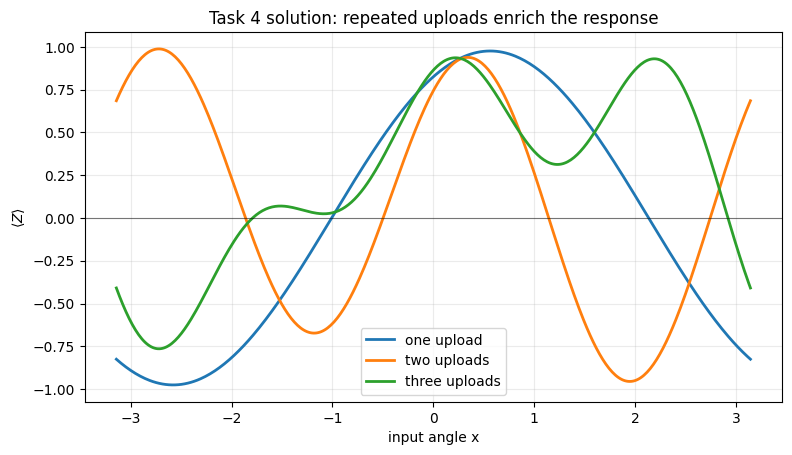

Turning points (via slope sign changes):
one upload : 2
two uploads: 4
three uploads: 6


In [5]:
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def one_upload_model(x, theta):
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[:3], wires=0)
    return qml.expval(qml.PauliZ(0))


@qml.qnode(dev)
def two_upload_model(x, theta):
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[:3], wires=0)
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[3:6], wires=0)
    return qml.expval(qml.PauliZ(0))


@qml.qnode(dev)
def three_upload_model(x, theta):
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[:3], wires=0)
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[3:6], wires=0)
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[6:9], wires=0)
    return qml.expval(qml.PauliZ(0))


def count_turning_points(values):
    slopes = np.diff(values)
    signs = np.sign(slopes)

    # Forward-fill zeros so flat segments do not create spurious sign changes
    for idx in range(1, len(signs)):
        if signs[idx] == 0:
            signs[idx] = signs[idx - 1]

    nonzero = signs[signs != 0]
    return np.sum(nonzero[1:] != nonzero[:-1])


theta_one = np.array([0.40, -0.60, 0.20])
theta_two = np.array([0.40, -0.60, 0.20, 1.10, -0.30, 0.70])
theta_three = np.array([0.40, -0.60, 0.20, 1.10, -0.30, 0.70, -0.80, 0.50, 1.20])
x_grid = np.linspace(-np.pi, np.pi, 400)

one_values = np.array([one_upload_model(x, theta_one) for x in x_grid])
two_values = np.array([two_upload_model(x, theta_two) for x in x_grid])
three_values = np.array([three_upload_model(x, theta_three) for x in x_grid])

plt.figure(figsize=(9, 4.8))
plt.plot(x_grid, one_values, label="one upload", linewidth=2)
plt.plot(x_grid, two_values, label="two uploads", linewidth=2)
plt.plot(x_grid, three_values, label="three uploads", linewidth=2)
plt.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
plt.xlabel("input angle x")
plt.ylabel(r"$\langle Z \rangle$")
plt.title("Task 4 solution: repeated uploads enrich the response")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print("Turning points (via slope sign changes):")
print("one upload :", count_turning_points(one_values))
print("two uploads:", count_turning_points(two_values))
print("three uploads:", count_turning_points(three_values))


The exact counts depend on the chosen parameters, but this turning-point diagnostic is a simple way to quantify how often the response curve changes from increasing to decreasing, or vice versa. If the three-upload curve bends more often, its slope will switch sign more often as well. That matches the design intuition behind re-uploading: extra uploads can increase functional flexibility on the same qubit register, at the cost of more depth and more parameters.

<a id="task5-solution"></a>

## Task 5 (design): One complete solution

**Scenario A.** A reasonable choice is a ZZ-style entangling feature map with a shallow configuration, for example one repetition and a sparse entanglement pattern. The qubit budget already matches the feature count, so there is no reason to spend depth on repeated uploads just to fit the data into the register. Since the task seems to depend on pairwise correlations, the encoding itself should expose those interactions early. The shallow-circuit constraint means the entangling pattern should stay modest.

**Scenario B.** A reasonable choice is data re-uploading, possibly starting from a local angle encoding and then repeating the upload across several trainable blocks. Here the main bottleneck is clearly qubit count, not depth, because four qubits cannot host eighteen continuous features in a simple one-shot local encoding. Re-uploading lets the same register interact with the data multiple times and is therefore the most natural way to trade qubits for depth. On a simulator, the additional depth is much less restrictive.

**Scenario C.** A reasonable choice is to start from plain angle encoding and add a small amount of re-uploading before turning to a heavy entangling map. The problem asks for more expressive power, but two-qubit gates are noisy, so a dense ZZ-style map may pay too much in hardware error. A one-qubit or mostly local re-uploading architecture can increase flexibility with fewer noisy entanglers. If later experiments show that pairwise correlations are truly essential, then only the lightest entangling structure that the device can tolerate should be added.